In [1]:
import pandas as pd
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer

from sklearn.metrics import classification_report, matthews_corrcoef
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import f1_score, confusion_matrix

In [2]:
#path = "ML_Assignment_2/"
#train_csv_path = os.path.join(path, "adult.csv")
train_csv_path = "adult.csv"
df = pd.read_csv(train_csv_path)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


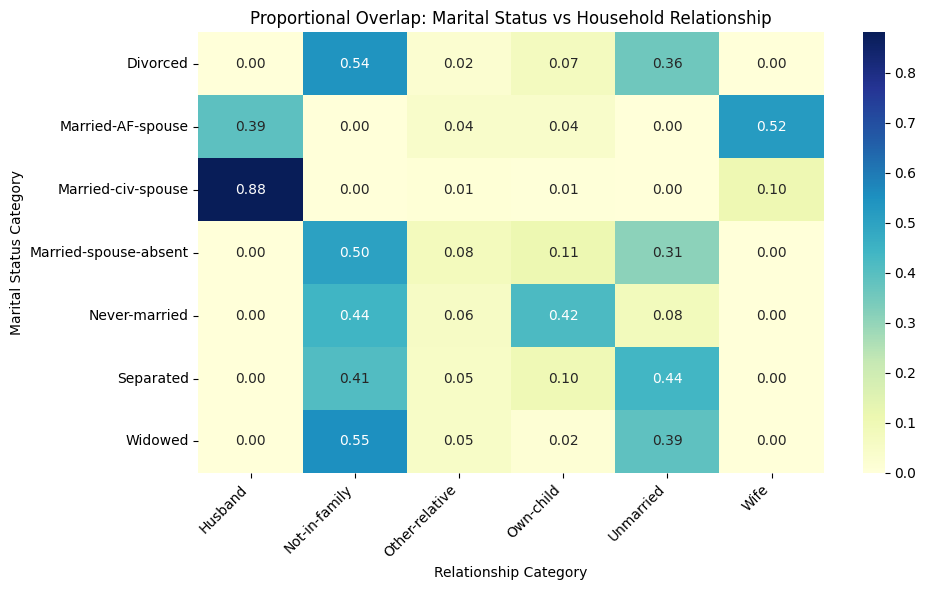

In [3]:
plt.figure(figsize=(10, 6))

# Normalize the crosstab by row totals to show percentages/proportions cleanly
normalized_crosstab = pd.crosstab(df['marital.status'], df['relationship'], normalize='index')

# Plot the heatmap
sns.heatmap(normalized_crosstab, annot=True, cmap="YlGnBu", fmt=".2f", cbar=True)

plt.title("Proportional Overlap: Marital Status vs Household Relationship")
plt.xlabel("Relationship Category")
plt.ylabel("Marital Status Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:
train_df = df.sample(frac=0.85, random_state=42)
test_df = df.drop(train_df.index)

In [5]:
test_df.to_csv("test.csv")

Data clean-up

In [7]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer


class IncomeDataTransformer(BaseEstimator, TransformerMixin):

    def __init__(self):
        # State placeholders to be saved
        self.country_mode_ = None
        self.occupation_imputer_ = None
        self.expected_columns_ = None
        self.categorical_features_ = None

    def _stateless_clean(self, df):
        """Performs initial operations that don't depend on data states."""
        df = df.copy()
        df["workclass"] = np.where(
            df["workclass"] == "?", "Unknown", df["workclass"]
        )
        df["fnlwgt_log"] = np.log1p(df["fnlwgt"])
        df["capital_gain_log"] = np.log1p(df["capital.gain"])
        df["capital_loss_log"] = np.log1p(df["capital.loss"])
        df["native.country"] = df["native.country"].str.strip().replace("?", np.nan)
        df["occupation"] = df["occupation"].replace("?", np.nan)

        if "income" in df.columns:
            df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})
        return df

    def fit(self, X, y=None):
        """Learns modes, imputer states, and exact dummy column schemas from X_train."""
        X_clean = self._stateless_clean(X)
        self.country_mode_ = X_clean["native.country"].mode()[0]
        X_clean["native.country"] = X_clean["native.country"].fillna(
            self.country_mode_
        )
        self.categorical_features_ = [
            col
            for col in X_clean.select_dtypes(include="object").columns
            if col != "occupation"
        ]
        self.occupation_imputer_ = SimpleImputer(strategy="most_frequent")
        self.occupation_imputer_.fit(X_clean[["occupation"]])
        X_clean["occupation"] = self.occupation_imputer_.transform(
            X_clean[["occupation"]]
        ).ravel()
        dummy_cols = self.categorical_features_ + ["occupation"]
        X_encoded = pd.get_dummies(X_clean, columns=dummy_cols, drop_first=True)

        cols_to_drop = [
            "fnlwgt",
            "capital.gain",
            "capital.loss",
        ]
        self.expected_columns_ = [
            c for c in X_encoded.columns if c not in cols_to_drop
        ]

        return self

    def transform(self, X):
        """Applies saved parameters to X_test with ZERO data leakage."""
        X_clean = self._stateless_clean(X)
        X_clean["native.country"] = X_clean["native.country"].fillna(
            self.country_mode_
        )
        X_clean["occupation"] = self.occupation_imputer_.transform(
            X_clean[["occupation"]]
        ).ravel()
        dummy_cols = self.categorical_features_ + ["occupation"]
        X_encoded = pd.get_dummies(X_clean, columns=dummy_cols, drop_first=True)
        X_final = X_encoded.reindex(
            columns=self.expected_columns_, fill_value=0
        )

        return X_final


In [8]:
target_column = "income"
counts = df[target_column].value_counts()
percentages = df[target_column].value_counts(normalize=True) * 100
balance_df = pd.DataFrame({'Counts': counts, 'Percentage (%)': percentages})
print(balance_df)

        Counts  Percentage (%)
income                        
<=50K    24720       75.919044
>50K      7841       24.080956


In [9]:
transformer = IncomeDataTransformer()
train_df = transformer.fit_transform(train_df)
test_df = transformer.transform(test_df)

In [10]:
# Visualize the relationship between features and target variables
def visualize_scatterplot(df, featureName, targetName):
  X = df[featureName]
  Y = df[targetName]

  plt.scatter(X, Y);
  plt.xlabel(featureName)
  plt.ylabel(targetName)
  plt.title(featureName + ' vs ' + targetName)
  plt.show()

def visualize_plot(df, featureName, targetName):
  X = df[featureName]
  Y = df[targetName]

  plt.plot(X, Y);
  plt.xlabel(featureName)
  plt.ylabel(targetName)
  plt.title(featureName + ' vs ' + targetName)
  plt.show()

def visualize_corr_heatmap(corr_matrix):
  plt.figure(figsize=(10, 8))
  sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
  plt.title('Correlation Heatmap')
  plt.show()

def visualize_histogram(df, featureName, targetName):
  plt.hist(df[featureName], bins=20)
  plt.xlabel(featureName)
  plt.ylabel('Frequency')
  plt.title(featureName + ' Distribution')
  plt.show()

def visualize_boxplot(df, featureName, targetName):
  plt.boxplot(df[featureName])
  plt.xlabel(featureName)
  plt.title(featureName + ' Boxplot')
  plt.show()

In [11]:
# Split data into train and test set
def split_train_test_data(df, test_size, target_column):
  X = df.drop(columns=[target_column])
  Y = df[target_column]
  X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=0)
  return X_train, X_test, Y_train, Y_test

# def one_hot_encoding(df, categorical_features, train_encoded):
#   if (train_encoded is None):
#     df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
#     df_encoded = df_encoded.reindex(columns=df_encoded.columns, fill_value=0)
#   else:
#     df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
#     df_encoded = df_encoded.reindex(columns=train_encoded.columns, fill_value=0)
#   return df_encoded

In [12]:
X_train, X_test, y_train, y_test = split_train_test_data(train_df, 0.15, 'income')

In [13]:
def model_fit_and_predict(X_train, y_train, X_test, model_name, model_dict):
  if (model_name == 'logistic_regression_l1'):
    model = LogisticRegression(C=0.1,
                             solver='saga',
                             l1_ratio=1,
                             class_weight='balanced',
                             max_iter=5000,
                             random_state=42)
  elif (model_name == 'logistic_regression_l2'):
    model = LogisticRegression(C=0.1,
                             solver='saga',
                             l1_ratio=0,
                             class_weight='balanced',
                             max_iter=5000,
                             random_state=42)
  elif (model_name == 'decision_tree'):
    model = DecisionTreeClassifier(random_state=42)
  elif (model_name == 'knn'):
    model = KNeighborsClassifier(n_neighbors=5)
  elif (model_name == 'naive_bayes'):
    model = GaussianNB()
  elif (model_name == 'random_forest'):
    model = RandomForestClassifier(n_estimators=100, max_depth=15,
                                   oob_score=False, random_state=42,
                                   min_samples_leaf = 10)

  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  y_pred_prob = model.predict_proba(X_test)
  model_dict[model_name] = model
  return model_dict, y_pred, y_pred_prob

In [14]:
def evaluate_model(y_test, y_pred):
  accuracy = accuracy_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  mcc = matthews_corrcoef(y_test, y_pred)

  return accuracy, recall, precision, f1, mcc

def print_evaluation_metrics(accuracy, recall, precision, f1, mcc, model_dict):
  for model_name in model_dict:
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy[model_name]:0.4f}")
    print(f"Recall: {recall[model_name]:0.4f}")
    print(f"Precision: {precision[model_name]:0.4f}")
    print(f"F1 Score: {f1[model_name]:0.4f}")
    print(f"MCC: {mcc[model_name]:0.4f}")
    print('******************************')

def get_metrics_dataframe(accuracy, recall, precision, f1, mcc, model_dict):
    rows = []
    for model_name in model_dict:
        rows.append({
            'Model Name': model_name,
            'Accuracy': accuracy[model_name],
            'Recall': recall[model_name],
            'Precision': precision[model_name],
            'F1 Score': f1[model_name],
            'MCC': mcc[model_name]
        })
    return pd.DataFrame(rows)

In [15]:
def plot_roc_curve(model_dict, X_test, y_test):
  fig, ax = plt.subplots(1, 1, figsize=(8, 6))
  for model_name, model in model_dict.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name)

  ax.plot([0, 1], [0, 1],color='gray', linestyle='--', label='Random Guess (AUC = 0.5)')
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve - Adult Income Model (All Models)")
  plt.grid(True, linestyle=":", alpha=0.6)
  plt.show()


In [16]:
list_of_models = ['logistic_regression_l1',
                  'logistic_regression_l2',
                  'decision_tree',
                  'knn',
                  'naive_bayes',
                  'random_forest']
model_dict = dict()
accuracy = dict()
recall = dict()
precision = dict()
f1 = dict()
mcc = dict()

for model_name in list_of_models:
  model_dict, y_pred, y_pred_prob = model_fit_and_predict(X_train, y_train, X_test, model_name, model_dict)
  accuracy[model_name], recall[model_name], precision[model_name], f1[model_name], mcc[model_name] = evaluate_model(y_test, y_pred)

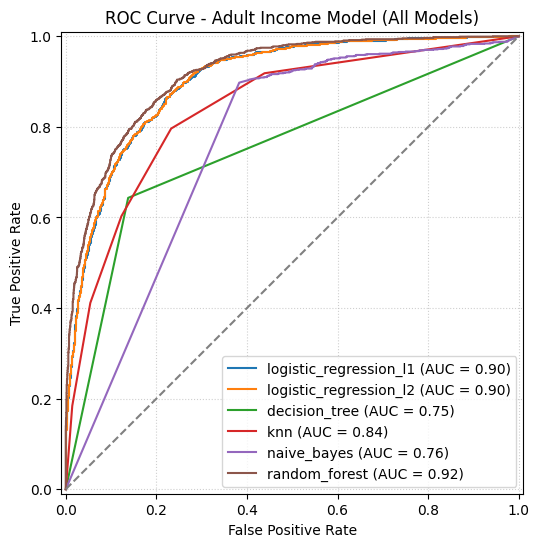

In [17]:
plot_roc_curve(model_dict, X_test, y_test)

In [18]:
metric_df = get_metrics_dataframe(accuracy, recall, precision, f1, mcc, model_dict)
display(metric_df)

,Model Name,Accuracy,Recall,Precision,F1 Score,MCC
0,logistic_regression_l1,0.801541,0.848826,0.576899,0.686930,0.571222
1,logistic_regression_l2,0.800819,0.846948,0.575990,0.685671,0.569310
2,decision_tree,0.806118,0.643192,0.617117,0.629885,0.498814
3,knn,0.806840,0.602817,0.628795,0.615532,0.486821
4,naive_bayes,0.546965,0.950235,0.356338,0.518310,0.336349
5,random_forest,0.854046,0.546479,0.825532,0.657627,0.589281


In [19]:
import joblib
path = ""
for model_name, model in model_dict.items():
  filepath = path + model_name + '_model.pkl'
  joblib.dump(model, filepath)

joblib.dump(transformer, path + "data_transformer.pkl")
print("Files successfully exported!")


Files successfully exported!


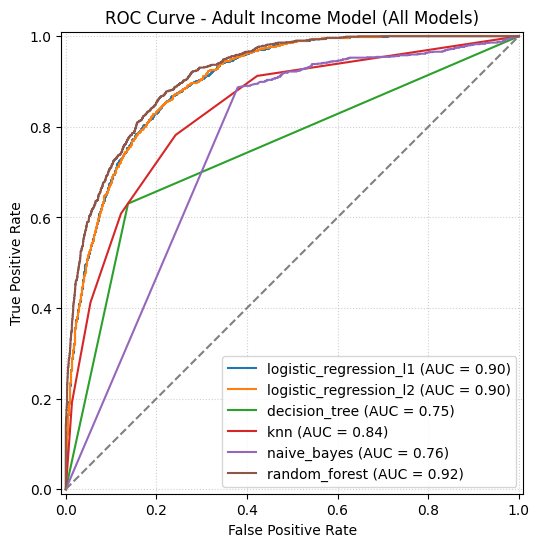

,Model Name,Accuracy,Recall,Precision,F1 Score,MCC
0,logistic_regression_l1,0.799959,0.847636,0.546584,0.664607,0.557340
1,logistic_regression_l2,0.801188,0.844133,0.548662,0.665057,0.557570
2,decision_tree,0.808354,0.630473,0.583468,0.606061,0.480317
3,knn,0.815111,0.608581,0.603823,0.606193,0.485399
4,naive_bayes,0.544431,0.942207,0.332612,0.491661,0.326903
5,random_forest,0.866298,0.567426,0.802974,0.664956,0.598251


In [20]:
test_df = pd.read_csv("test.csv")
test_df = transformer.transform(test_df)

model_dict_test = dict()
for model in list_of_models:
  filepath = path + model + '_model.pkl'
  model_dict_test[model] = joblib.load(filepath)

# Re-initialize these dictionaries to avoid TypeError if they were overwritten
accuracy = dict()
recall = dict()
precision = dict()
f1 = dict()
mcc = dict()

for model in model_dict:
  y_pred = model_dict_test[model].predict(test_df.drop(columns=['income']))
  y_pred_prob = model_dict_test[model].predict_proba(test_df.drop(columns=['income']))
  accuracy[model], recall[model], precision[model], f1[model], mcc[model] = evaluate_model(test_df['income'], y_pred)

plot_roc_curve(model_dict_test, test_df.drop(columns=['income']), test_df['income'])

# The get_metrics_dataframe function also expects a dictionary of models,
# so we need to adjust the call similarly. Use model_dict_test instead of the undefined model_test.
metric_test_df = get_metrics_dataframe(accuracy, recall, precision, f1, mcc, model_dict_test)
display(metric_test_df)